# 1. Filter on fame_fixed

In [26]:
# Load fame_fixed table from duckdb
# Print the number of rows
import ibis
from utils.f_0_dirs import get_data_dirs

dirs = get_data_dirs()
con = ibis.duckdb.connect(str(dirs.db_path))
fame_fixed = con.table("fame_fixed")
if fame_fixed is None:
    raise ValueError("fame_fixed table not found in the database.")

fixed_count_start = fame_fixed.count().execute()
print(f"Number of rows in fame_fixed before filtering: {fixed_count_start:,}")

fame_fixed_running = fame_fixed

Number of rows in fame_fixed before filtering: 9,795,622


In [ ]:
import pandas as pd

# ==========================================
# 1. EXTRACT & COUNT COUNTRY CODES
# ==========================================
print("🔍 Extracting country codes and generating counts...")

# Use regex to grab any leading letters or the '#' symbol
table_with_cc = fame_fixed_running.mutate(
    country_code = fame_fixed_running.registered_number.re_extract(r'^([A-Za-z\#]+)', 1)
)

# Aggregate and execute to Pandas
cc_counts = (
    table_with_cc.group_by("country_code")
    .aggregate(count=table_with_cc.count())
    .execute()
)

# ==========================================
# 2. FILTER OUT FOREIGN FIRMS
# ==========================================
# Define standard UK prefixes (England/Wales are pure numbers, handled by isnull)
uk_prefixes = [
    '',   # England & Wales (pure numbers)
    'NI', # Northern Ireland Company (post-partition)
    'SC', # Scottish Company
    'OC', # Limited Liability Partnership - LLP (England & Wales)
    'SO', # Limited Liability Partnership - LLP (Scotland)
    'NC', # Limited Liability Partnership - LLP (Northern Ireland)
    'LP', # Limited Partnership (England & Wales)
    'SL', # Limited Partnership (Scotland)
    'ZC', # Unregistered Companies (Section 1043) for England & Wales
    'SZ', # Scottish Unregistered Companies (Section 1043)
    'SG', # Scottish Qualifying Partnership
    'CE', # Charitable Incorporated Organisation (England & Wales)
    'CS', # Scottish Charitable Incorporated Organisation
    'R',  # Older Northern Ireland company (no longer issued)
    'IP'  # Industrial and Provident Societies (cooperatives)
]
non_uk_prefixes = [
    'IE', # Ireland
    'JE', # Jersey
    'IM', # Isle of Man
    'GG', # Guernsey
    'GI', # Gibraltar,
    'SE'  # Société Européenne (European Company),
    '#',  # Foreign legal entites that are traded on LSEG
]

# Format the NaN values (pure numbers) for clean viewing
cc_counts["country_code"] = cc_counts["country_code"].fillna("None at all (All numbers)")
cc_counts = cc_counts.sort_values(by="count", ascending=False).reset_index(drop=True)
uk_cc_counts = cc_counts[cc_counts["country_code"].isin(uk_prefixes + ["None at all (All numbers)"])]
non_uk_cc_counts = cc_counts[cc_counts["country_code"].isin(non_uk_prefixes)]
non_uk_count = non_uk_cc_counts["count"].sum()
non_uk_total = pd.DataFrame({"country_code": ["Total Non-UK"], "count": non_uk_count})
non_uk_cc_counts = pd.concat([non_uk_cc_counts, non_uk_total], ignore_index=True)
print("📊 UK prefix Counts in fame_fixed:")
display(uk_cc_counts)
print("📊 Non-UK prefix Counts in fame_fixed:")
display(non_uk_cc_counts)

# Keep rows where prefix is missing (pure numbers) OR is a known UK prefix
# Then immediately drop the temporary 'country_code' column so it doesn't pollute the schema
table_fame_fixed_filtered = table_with_cc.filter(
    # Remove rows where country_code is not in non_uk_prefixes using ibis method
    table_with_cc.country_code.isin(uk_prefixes)
).drop("country_code")

# Print and compare row count
filtered_count = table_fame_fixed_filtered.count().execute()
print(f"Number of rows in fame_fixed after filtering: {filtered_count:,}")

if fixed_count_start - filtered_count != non_uk_count:
    print(f"Pre-filtering count: {fixed_count_start:,}, Post-filtering count: {filtered_count:,}, Non-UK count: {non_uk_count:,}")
    # raise ValueError("Row count mismatch after filtering. Please check the filtering logic.")

# # Find rows that have unknown prefixes and print 20 of them each for inspection
# for prefix in non_uk_prefixes:
#     prefix_count = cc_counts.loc[cc_counts['country_code'] == prefix, 'count'].sum()
#     prefix_frac = 20 / prefix_count if prefix_count > 20 else 1
#     unknown_rows = table_with_cc.filter(table_with_cc.country_code == prefix).sample(prefix_frac).execute()
#     if not unknown_rows.empty:
#         print(f"⚠️ Found {len(unknown_rows)} rows with unknown prefix '{prefix}':")
#         display(unknown_rows)

fame_fixed_running = table_fame_fixed_filtered

🔍 Extracting country codes and generating counts...
📊 UK prefix Counts in fame_fixed:


,country_code,count
0,,9163650
1,SC,514786
2,NI,116311
3,SO,260
4,R,169
7,ZC,77
12,SZ,4
13,IP,2


📊 Non-UK prefix Counts in fame_fixed:


,country_code,count
0,JE,109
1,IM,51
2,GG,42
3,GI,4
4,Total Non-UK,206


Number of rows in fame_fixed after filtering: 9,795,259
Pre-filtering count: 9,795,622, Post-filtering count: 9,795,259, Non-UK count: 206


In [ ]:
# Write fame_yearly_running to a new table in duckdb called fame_yearly_filtered
con.create_table("fame_fixed_filtered", fame_fixed_running, overwrite=True)

# 2. Filter on fame_yearly

In [6]:
# Load fame_yearly table from duckdb
# Print the number of rows
import ibis
from utils.f_0_dirs import get_data_dirs

dirs = get_data_dirs()
con = ibis.duckdb.connect(str(dirs.db_path))
fame_yearly = con.table("fame_yearly")
if fame_yearly is None:
    raise ValueError("fame_yearly table not found in the database.")

yearly_count_start = fame_yearly.count().execute()
print(f"Number of rows in fame_yearly before filtering: {yearly_count_start:,}")

fame_yearly_running = fame_yearly

Number of rows in fame_yearly before filtering: 40,846,539


### Drop small companies (<10 employees)

In [7]:
# Drop any row in fame_yearly where employees is NaN or <10, as these are likely to be small companies that are not relevant for our analysis.

fame_yearly_no_small = fame_yearly_running.filter(
    (fame_yearly_running['employees'].isnull() == False) & (fame_yearly_running['employees'] >= 10)
)
yearly_count_no_small = fame_yearly_no_small.count().execute()
print(f"Number of rows in fame_yearly after filtering small companies: {yearly_count_no_small:,}")

fame_yearly_running = fame_yearly_no_small

Number of rows in fame_yearly after filtering small companies: 2,526,335


### Drop missing data (for productivity)
- GVA (Lars): renumeration_employees + ebitda
- GVA (bottom-up): profit_loss_pretax + interest_paid + depreciation + remuneration_employees
- Productivity: GVA / employees
- Average wage: renumeration_employees / employees

In [8]:
# - GVA (Lars): renumeration_employees + ebitda
# - GVA (bottom-up): profit_loss_pretax + interest_paid + depreciation + remuneration_employees
# - Productivity: GVA / employees
# - Average wage: renumeration_employees / employees
# Drop any row which is missing (renumeration_employees and ebitda) or (profit_loss_pretax, interest_paid, depreciation, remuneration_employees), as these are needed to calculate gva.

fame_yearly_no_missing = fame_yearly_running.filter(
    (
        (fame_yearly_running['remuneration_employees'].isnull() == False) &
        (fame_yearly_running['ebitda'].isnull() == False)
    ) | (
        (fame_yearly_running['profit_loss_pretax'].isnull() == False) &
        (fame_yearly_running['interest_paid'].isnull() == False) &
        (fame_yearly_running['depreciation'].isnull() == False) &
        (fame_yearly_running['remuneration_employees'].isnull() == False)
    )
)
yearly_count_no_missing = fame_yearly_no_missing.count().execute()
print(f"Number of rows in fame_yearly after filtering missing data: {yearly_count_no_missing:,}")

fame_yearly_running = fame_yearly_no_missing

Number of rows in fame_yearly after filtering missing data: 1,165,056


### Output filtered yearly table

In [21]:
# Write fame_yearly_running to a new table in duckdb called fame_yearly_filtered
con.create_table("fame_yearly_filtered", fame_yearly_running, overwrite=True)

DatabaseTable: fame_data.main.fame_yearly_filtered
  registered_number            string
  year                         int64
  consolidated                 boolean
  turnover                     float64
  shareholders_funds           float64
  profit_loss_pretax           float64
  employees                    int64
  tangibles                    float64
  tangibles_land_and_buildings float64
  tangibles_land_freehold      float64
  tangibles_land_leasehold     float64
  tangibles_fixt_fit           float64
  tangibles_plant_and_vehicles float64
  tangibles_plant              float64
  tangibles_vehicles           float64
  fixed_other                  float64
  intangibles                  float64
  investments_other            float64
  fixed_total                  float64
  liabilities                  float64
  total_assets                 float64
  liabilites_lt                float64
  cos                          float64
  admin_expenses               float64
  interest_paid                float64
  profit_loss_pretax2          float64
  tax                          float64
  dividends                    float64
  depreciation                 float64
  r_and_d                      float64
  remuneration_employees       float64
  wages                        float64
  social_security_costs        float64
  pensions_costs               float64
  other_staff_costs            float64
  renumeration_directors       float64
  ebitda                       float64

### Stats on filtered yearly table

Number of rows in fame_yearly after filtering: 1,165,056
Number of unique firms (registered_numbers) in fame_yearly after filtering: 157,195
📊 Calculating distribution of years per firm...
📈 Calculating distribution of active firms per year...


DatabaseTable: fame_data.main.fame_yearly_filtered
  registered_number            string
  year                         int64
  consolidated                 boolean
  turnover                     float64
  shareholders_funds           float64
  profit_loss_pretax           float64
  employees                    int64
  tangibles                    float64
  tangibles_land_and_buildings float64
  tangibles_land_freehold      float64
  tangibles_land_leasehold     float64
  tangibles_fixt_fit           float64
  tangibles_plant_and_vehicles float64
  tangibles_plant              float64
  tangibles_vehicles           float64
  fixed_other                  float64
  intangibles                  float64
  investments_other            float64
  fixed_total                  float64
  liabilities                  float64
  total_assets                 float64
  liabilites_lt                float64
  cos                          float64
  admin_expenses               float64
  interest_paid                float64
  profit_loss_pretax2          float64
  tax                          float64
  dividends                    float64
  depreciation                 float64
  r_and_d                      float64
  remuneration_employees       float64
  wages                        float64
  social_security_costs        float64
  pensions_costs               float64
  other_staff_costs            float64
  renumeration_directors       float64
  ebitda                       float64

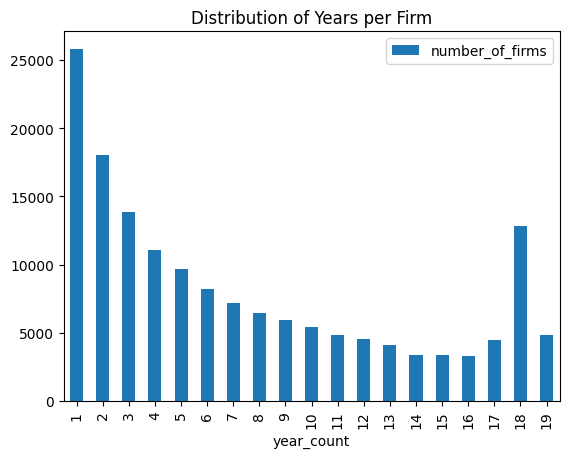

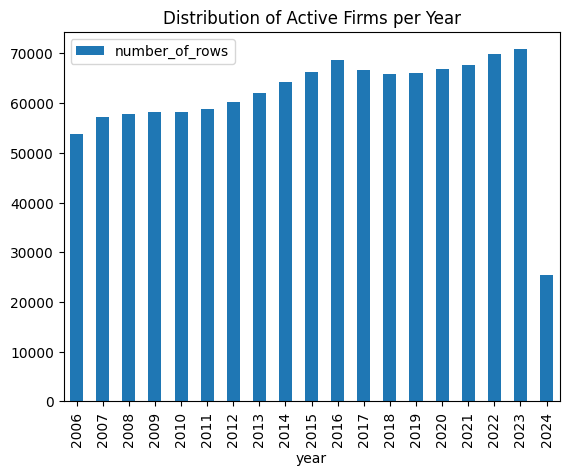

In [ ]:
yearly_count_end = fame_yearly_running.count().execute()
print(f"Number of rows in fame_yearly after filtering: {yearly_count_end:,}")

# How many unique registered_numbers are left after filtering?
unique_registered_numbers = fame_yearly_running['registered_number'].nunique().execute()
print(f"Number of unique firms (registered_numbers) in fame_yearly after filtering: {unique_registered_numbers:,}")

# Group the rows by registered_numbers. What is the distribution of the number of rows per registered_number?
# Sum the number of firms which have 1 row, 2 rows, 3 rows, etc. to get the distribution of years for each firm.

print("📊 Calculating distribution of years per firm...")
# Step 1: Count how many rows (years) exist for each firm
years_per_firm = fame_yearly_running.group_by("registered_number").aggregate(year_count=fame_yearly_running.count())

# Step 2: Group by the year_count to see how many firms have exactly 1 year, 2 years, etc.
firm_year_distribution = (
    years_per_firm.group_by("year_count")
    .aggregate(number_of_firms=years_per_firm.count())
    .order_by("year_count")
    .execute()
)
firm_year_distribution.plot.bar(x="year_count", y="number_of_firms", title="Distribution of Years per Firm")

# Group the rows by year. What is the distribution of the number of rows per year?
print("📈 Calculating distribution of active firms per year...")
rows_per_year_distribution = (
    fame_yearly_running.group_by("year")
    .aggregate(number_of_rows=fame_yearly_running.count())
    .order_by("year")
    .execute()
)
rows_per_year_distribution.plot.bar(x="year", y="number_of_rows", title="Distribution of Active Firms per Year")

# 2. Write filter to both databases

In [ ]:
import ibis
from utils.f_0_dirs import get_data_dirs

dirs = get_data_dirs(segment="build")
con = ibis.duckdb.connect(str(dirs.db_path))
con.raw_sql("PRAGMA memory_limit='12GB'")

# 1. Connect to the existing fame_fixed and fame_yearly tables in duckdb
fame_fixed_running = con.table("fame_fixed")
fame_yearly_running = con.table("fame_yearly")

fixed_cols = list(fame_fixed_running.columns)
yearly_cols = list(fame_yearly_running.columns)

start_fixed_count = con.table("fame_fixed").count().execute()
start_yearly_count = con.table("fame_yearly").count().execute()
print(f"📊 Initial firm count (fame_fixed): {start_fixed_count:,}")
print(f"📊 Initial panel row count (fame_yearly): {start_yearly_count:,}")

# 2. Do a merge on registered_number between fame_fixed_running and fame_yearly_running
# This builds the AST and ensures only firms present in BOTH tables survive.
table_merged = fame_fixed_running.inner_join(fame_yearly_running, "registered_number")

fame_fixed_filtered = table_merged.select(fixed_cols).distinct()
fame_yearly_filtered = table_merged.select(yearly_cols)

# ==========================================
# SAFE TABLE OVERWRITE PROCEDURE
# ==========================================

print("💾 Safely overwriting fame_fixed...")
con.create_table("fame_fixed_clean", fame_fixed_filtered, overwrite=True)
con.drop_table("fame_fixed")
con.create_table("fame_fixed", con.table("fame_fixed_clean"), overwrite=True)
con.drop_table("fame_fixed_clean")
print("✅ fame_fixed updated successfully.")

print("💾 Safely overwriting fame_yearly...")
con.create_table("fame_yearly_clean", fame_yearly_filtered, overwrite=True)
con.drop_table("fame_yearly")
con.create_table("fame_yearly", con.table("fame_yearly_clean"), overwrite=True)
con.drop_table("fame_yearly_clean")
print("✅ fame_yearly updated successfully.")

# Verification
final_fixed_count = con.table("fame_fixed").count().execute()
final_yearly_count = con.table("fame_yearly").count().execute()
print(f"📊 Final firm count (fame_fixed): {final_fixed_count:,}")
print(f"📊 Final panel row count (fame_yearly): {final_yearly_count:,}")